## **Assignment 3**


---

Sakshi Heda (200070071)

In [1]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import pywt
import pywt.data
from PIL import Image, ImageFilter
from google.colab import files as FILE
import requests
from numpy.lib import imag

In [2]:
img_data = requests.get("https://github.com/sakshiheda/EE610/blob/main/Image_orig.jpg?raw=true").content
with open('image1.jpg', 'wb') as handler:
  handler.write(img_data)
imgOrig_ques1 = cv2.imread("/content/image1.jpg")
imgOrig_ques1Gray = cv2.imread("/content/image1.jpg",0)
img1 = cv2.imread("/content/image1.jpg")
#cv2_imshow(imgOrig_ques1Gray)
imgOrig_ques1.shape

(178, 284, 3)

## **Question 1**


First of all I wrote the function for adding Gaussian noise using numpy library

In [3]:
# mu is the mean
# std is the standard deviation
mu=0.0
std = 10
def gaussian_noise(x,mu,std):
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    return x_noisy

https://stats.stackexchange.com/questions/548619/how-to-add-and-vary-gaussian-noise-to-input-data

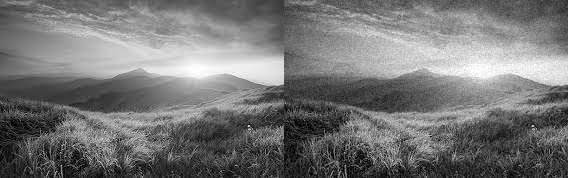

In [4]:
image_noise=gaussian_noise(imgOrig_ques1Gray,mu,std)
x = np.concatenate((imgOrig_ques1Gray, image_noise), axis=1)
cv2_imshow(x)

In [5]:
kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])

For restoring the original image, I used the method of Gaussian blurring with kernel of size 3X3 and 0 variance and then sharpened it. We can see the effect of both the methods


In [6]:
img1_gaussianRec = cv2.GaussianBlur(image_noise, (3,3), 0)
img1_gaussian_sharp = cv2.filter2D(src=img1_gaussianRec, ddepth=-1, kernel=kernel)

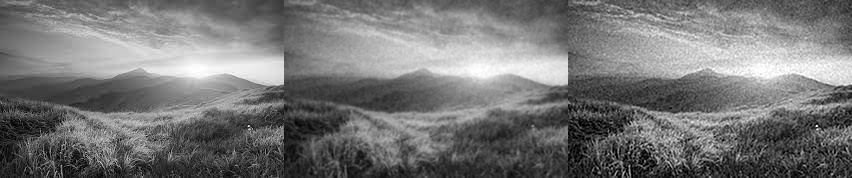

In [7]:
x = np.concatenate((imgOrig_ques1Gray, img1_gaussianRec, img1_gaussian_sharp), axis=1)
cv2_imshow(x)

Peak signal-to-noise ratio (PSNR) is the ratio between the maximum possible power of an image and the power of corrupting noise that affects the quality of its representation. 

In [4]:
peak = 255
def PSNR(orig, restored):
  # l, w = orig.shape
  sqrError = (orig - restored)**2
  mse = np.mean(sqrError)
  psnr = 10*np.log10(peak**2/mse)
  return psnr

PSNR between original and restored image

In [9]:
x_gaussian = PSNR(imgOrig_ques1Gray, img1_gaussianRec)
x_sharpen = PSNR(imgOrig_ques1Gray, img1_gaussian_sharp)
print(x_gaussian, x_sharpen)

26.853196139148686 25.61987288854941


We can see that we get better PSNR for image which was not sharpend and it is visible in the images also

The Structural Similarity Index (SSIM)
 is a perceptual metric that quantifies image quality degradation* caused by processing such as data compression or by losses in data transmission.

In [4]:
#SH
def l_xy(x, y, c):
  mu_x = np.mean(x)
  mu_y = np.mean(y)
  l = (2*mu_x*mu_y + + c)/(mu_x**2 + mu_y**2 + c)
  return l

def c_xy(x, y, c):
  sigma_x = np.std(x)
  sigma_y = np.std(y)
  c = (2*sigma_x*sigma_y + c)/(sigma_x**2 +sigma_y**2 + c)
  return c

def s_xy(x, y, c):
  sigma_x = np.std(x)
  sigma_y = np.std(y)
  # sigma_xy = signal.correlate2d(x, y)
  sigma_xy = np.corrcoef(x.flatten(), y.flatten())*sigma_x*sigma_y
  # print(sigma_xy)
  s = (sigma_xy[0][1] + c)/(sigma_x*sigma_y + c)

  return s

def SSIM(x, y, c1, c2, c3):
  ssim = l_xy(x, y, c1)*c_xy(x, y, c2)*s_xy(x, y, c3)
  return ssim

In [11]:
#SH
a = l_xy(imgOrig_ques1Gray, img1_gaussianRec, 6)
b = c_xy(imgOrig_ques1Gray, img1_gaussianRec, 6)
c = s_xy(imgOrig_ques1Gray, img1_gaussianRec, 3)
# print(c)
y_gaussian = SSIM(imgOrig_ques1Gray, img1_gaussianRec, 6, 6, 3)
y_sharpen = SSIM(imgOrig_ques1Gray, img1_gaussian_sharp, 6, 6, 3)
print(y_gaussian, y_sharpen)

0.9775717092835513 0.9717798374182045


Ques 1(d):Gaussian Blurring

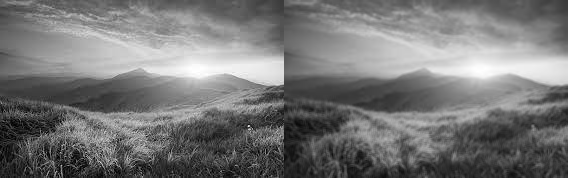

In [11]:
std = 10
img1_gaussianBlur = cv2.GaussianBlur(imgOrig_ques1Gray, (3,3), std)
x = np.concatenate((imgOrig_ques1Gray, img1_gaussianBlur), axis=1)
cv2_imshow(x)

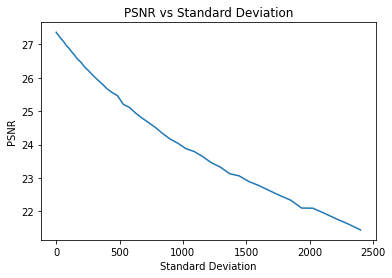

In [12]:
std=0
psnr_val = []
std_val = []
while(std < 50):
  imageNoise = gaussian_noise(imgOrig_ques1Gray, 0, std)
  img1_gaussianRec = cv2.GaussianBlur(imageNoise, (3,3), 0)
  psnr_val.append(PSNR(imgOrig_ques1Gray, img1_gaussianRec))
  std_val.append(std)
  std += 1

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_val)
plt.xlabel('Standard Deviation')
plt.ylabel('PSNR')
plt.title('PSNR vs Standard Deviation')
plt.show()

We can see that as variance of noise in the image increases, PSNR degrades

## **Question 2**

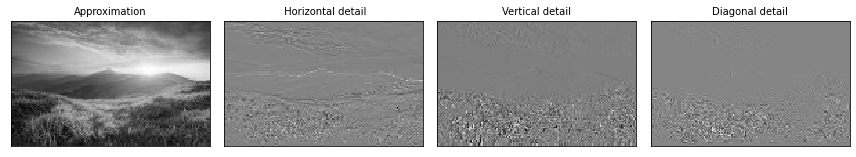

In [5]:
cA, cD = pywt.dwt(imgOrig_ques1Gray, 'db1')

# Wavelet transform of image, and plot approximation and details
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeffs2 = pywt.dwt2(imgOrig_ques1Gray, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()

In [6]:
#Adding noise to image
mu = 0.0
std = 15
imageNoise = gaussian_noise(imgOrig_ques1Gray, mu, std)

Part a: Hard Thresholding

(182, 288)


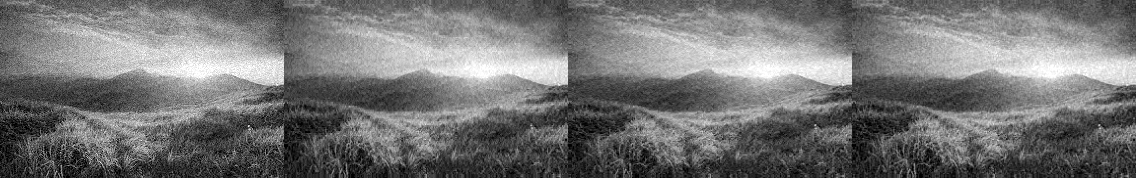

In [7]:
thr = 25

def hardThreshold(arr, thr):
  for i in range (len(arr)):
    for j in range (len(arr[0])):
      if (arr[i][j] < thr):
        arr[i][j] =0
  return arr

#LH coefficients
coeff = pywt.dwt2(imageNoise, 'bior1.3')
LL, (LH, HL, HH) = coeff
coeff_hard = LL, (hardThreshold(LH, thr), HL, HH)
img_wavHardLH = pywt.idwt2(coeff_hard, 'haar')
print(img_wavHardLH.shape)
img_wavHardLH = cv2.resize(img_wavHardLH, (284, 178))

#HL coefficients
coeffs2 = pywt.dwt2(imageNoise, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
coeff_hard = LL, (LH, hardThreshold(HL, thr), HH)
img_wavHardHL = pywt.idwt2(coeff_hard, 'haar')
img_wavHardHL=cv2.resize(img_wavHardHL, (284, 178))

#HH coefficients
coeff = pywt.dwt2(imageNoise, 'bior1.3')
LL, (LH, HL, HH) = coeff
coeff_hard = LL, (LH, HL, hardThreshold(HH, thr))
img_wavHardHH = pywt.idwt2(coeff_hard, 'haar')
img_wavHardHH = cv2.resize(img_wavHardHH, (284, 178))

x = np.concatenate((imageNoise, img_wavHardLH, img_wavHardHL, img_wavHardHH), axis=1)
cv2_imshow(x)

Here the first image is the image with noise while the rest three are obtained on hard thresholding of LH, HL and HH components of the wavelet transformation respectively. Next I have calculated PSNR for all the three restored images.

In [14]:
print(PSNR(imgOrig_ques1Gray, img_wavHardLH))
print(PSNR(imgOrig_ques1Gray, img_wavHardHL))
print(PSNR(imgOrig_ques1Gray, img_wavHardHH))

21.777573520155933
21.783764626641293
21.579322009177353


Though we cant see any visible difference between images we can see that there is difference in the pixels as shown below

In [15]:
x = img_wavHardLH - img_wavHardHL
print(np.max(x) - np.min(x))

133.81004972461457


Part b: Soft Thresholding

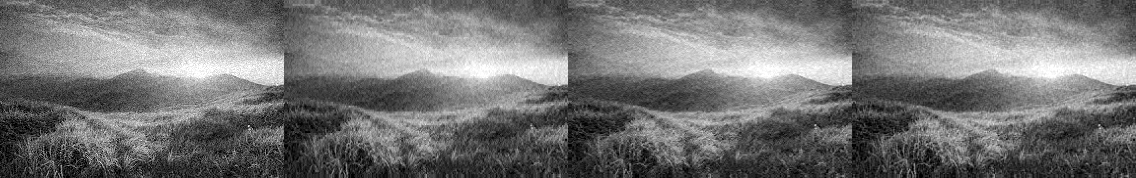

In [8]:
thr = 25

def softThreshold(arr, thr):
  for i in range (len(arr)):
    for j in range (len(arr[0])):
      if (arr[i][j] < thr):
        arr[i][j] = 0
      else:
        arr[i][j] = arr[i][j] - thr
  return arr

#LH coefficients
coeff = pywt.dwt2(imageNoise, 'bior1.3')
LL, (LH, HL, HH) = coeff
coeff_soft = LL, (softThreshold(LH, thr), HL, HH)
img_wavSoftLH = pywt.idwt2(coeff_soft, 'haar')
img_wavSoftLH=cv2.resize(img_wavSoftLH, (284, 178))

#HL coefficients
coeff = pywt.dwt2(imageNoise, 'bior1.3')
LL, (LH, HL, HH) = coeff
coeff_soft = LL, (LH, softThreshold(HL, thr), HH)
img_wavSoftHL = pywt.idwt2(coeff_soft, 'haar')
img_wavSoftHL=cv2.resize(img_wavSoftHL, (284, 178))

#HH coefficients
coeff = pywt.dwt2(imageNoise, 'bior1.3')
LL, (LH, HL, HH) = coeff
coeff_soft = LL, (LH, HL, softThreshold(HH, thr))
img_wavSoftHH = pywt.idwt2(coeff_soft, 'haar')
img_wavSoftHH=cv2.resize(img_wavSoftHH, (284, 178))

x = np.concatenate((imageNoise, img_wavSoftLH, img_wavSoftHL, img_wavSoftHH), axis=1)
cv2_imshow(x)

Here also, the first image is the image with noise while the rest three are obtained on hard thresholding of LH, HL and HH components of the wavelet transformation respectively. Next I have calculated PSNR for all the three restored images.

Source: https://pywavelets.readthedocs.io/en/latest/ref/2d-dwt-and-idwt.html, https://pywavelets.readthedocs.io/en/latest/#:~:text=PyWavelets%20is%20open%20source%20wavelet,%3E%20cA%2C%20cD%20%3D%20pywt.

In [19]:
print(PSNR(imgOrig_ques1Gray, img_wavSoftLH))
print(PSNR(imgOrig_ques1Gray, img_wavSoftHL))
print(PSNR(imgOrig_ques1Gray, img_wavSoftHH))

21.951486714021637
21.946061642257288
21.655106667486113


## **Question 3**

Here is the function for adding noise to an RGB image, source: https://splunktool.com/add-noise-to-rgb-image-in-python

In [9]:
#SH
mu=0.0
std = 25
def gaussian_noise_RGB(x,mu,std):
  x_noisy_RGB = x
  noise = np.random.normal(mu, std, size = x.shape[0:2])
  x_noisy_RGB[:, :, 0] = x[:, :, 0] + noise
  x_noisy_RGB[:, :, 1] = x[:, :, 1] + noise
  x_noisy_RGB[:, :, 2] = x[:, :, 2] + noise
  cv2.normalize(x_noisy_RGB, x_noisy_RGB, 0, 255, cv2.NORM_MINMAX, dtype = -1)
  x_noisy_RGB = x_noisy_RGB.astype(np.uint8)
  return x_noisy_RGB

Adding noise to RGB image

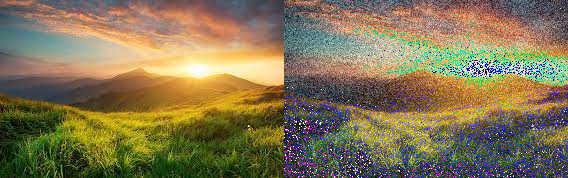

In [10]:
image_noise_RGB = gaussian_noise_RGB(imgOrig_ques1, mu, std)
x = np.concatenate((img1, image_noise_RGB), axis=1)
cv2_imshow(x)

Removing noise using Gaussian blur

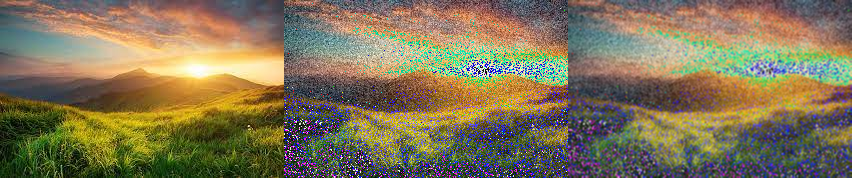

In [11]:
img1_gaussianRecRGB = cv2.GaussianBlur(image_noise_RGB, (3,3), 0)
x = np.concatenate((img1, image_noise_RGB, img1_gaussianRecRGB), axis=1)
cv2_imshow(x)

For the plot I varied the standard deviation from 0 to 50 in steps of one and plotted PSNR vs variance followed by SSIM vs Variance

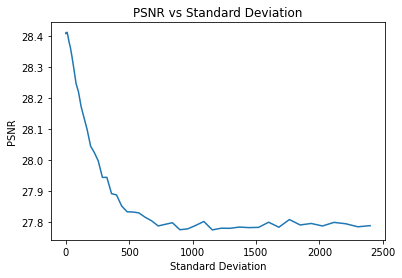

In [23]:
std=0
psnr_val=[]
std_val=[]
while(std < 50):
  image_noise_RGB = gaussian_noise_RGB(imgOrig_ques1,0,std)
  img1_gaussianRecRGB = cv2.GaussianBlur(image_noise_RGB, (3,3), 0)
  psnr_val.append(PSNR(imgOrig_ques1, img1_gaussianRecRGB))
  std_val.append(std)
  std += 1

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_val)
plt.xlabel('Standard Deviation')
plt.ylabel('PSNR')
plt.title('PSNR vs Standard Deviation')
plt.show()

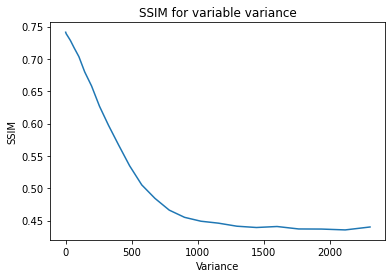

In [12]:
#Calculating PSNR for variable variance RGB
#Calculating PSNR for variable variance
std=0
ssim_arr=[]
std_arr=[]
while(std<50):
  image_noise=gaussian_noise_RGB(imgOrig_ques1,0,std)
  img1_gaussianRecRGB = cv2.GaussianBlur(image_noise, (3,3), 0)
  ssim_arr.append(SSIM(imgOrig_ques1, img1_gaussianRecRGB, 10, 10, 5))
  std_arr.append(std)
  std+=2

var_arr=np.square(std_arr)
plt.plot(var_arr,ssim_arr)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM for variable variance')
plt.show()

Part b: Gaussian Low pass filtering

28.383593873934828


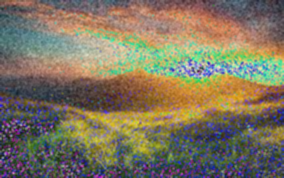

In [20]:
img1_gaussian = cv2.GaussianBlur(imgOrig_ques1,   (3,3), 1)
print(PSNR(imgOrig_ques1, img1_gaussian))
cv2_imshow(img1_gaussian)

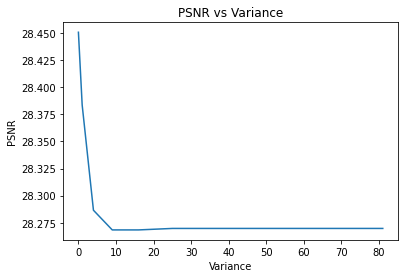

In [22]:
std=0
psnr_arr=[]
std_arr=[]
while(std < 10):
  img1_gaussian = cv2.GaussianBlur(imgOrig_ques1, (3,3), std)
  psnr_arr.append(PSNR(imgOrig_ques1, img1_gaussian))
  std_arr.append(std)
  std+=1

var_arr=np.square(std_arr)
plt.plot(var_arr,psnr_arr)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR vs Variance')
plt.show()

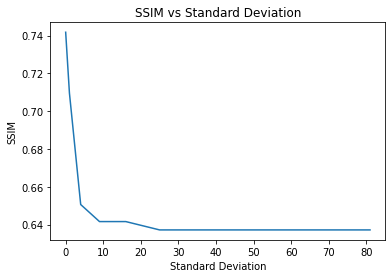

In [8]:
std=0
ssim_arr=[]
std_arr=[]
while(std<10):
  img1_gaussian = cv2.GaussianBlur(imgOrig_ques1, (3,3), std)
  ssim_arr.append(SSIM(imgOrig_ques1, img1_gaussian, 10, 10, 5))
  std_arr.append(std)
  std+=1

var_arr=np.square(std_arr)
plt.plot(var_arr,ssim_arr)
plt.xlabel('Standard Deviation')
plt.ylabel('SSIM')
plt.title('SSIM vs Standard Deviation')
plt.show()

Above are the plots obtained on varying the variance (standard deviation) in the gaussian filtering of the above RGB image

Part c: Taking Wavelet Transform

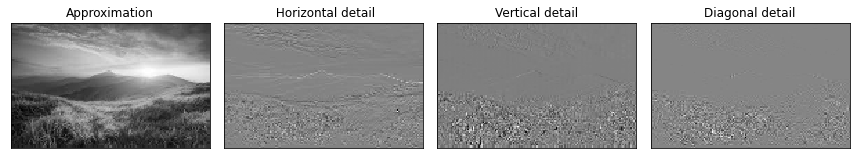

In [23]:
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeff = pywt.dwt2(imgOrig_ques1Gray, 'bior1.3')
LL, (LH, HL, HH) = coeff
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i])
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()

Soft Thresholding


---
Threshold = 𝜎 sqrt(2 log 𝑛2)


In [10]:
def threshold(sigma, n):
  sigma_sq = std**2  #noise variance
  lamda = sigma*np.sqrt(2*np.log(n**2)) 
  return lamda 

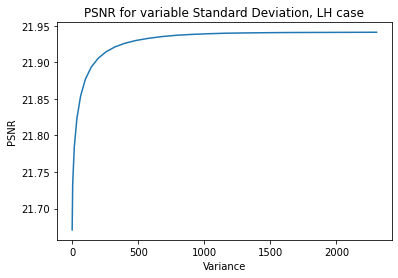

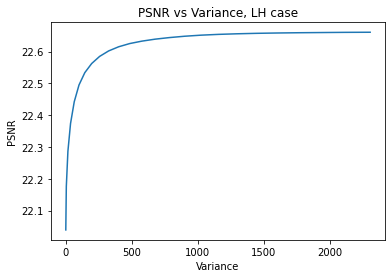

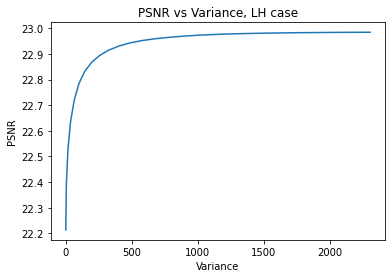

In [12]:
std=0
psnr_valLH=[]
psnr_valHL=[]
psnr_valHH=[]
std_val=[]
while(std < 50):
  coeff = pywt.dwt2(imageNoise, 'bior1.3')
  LL, (LH, HL, HH) = coeff
  # print(LH.shape)

  coeff_SoftLH = LL, (softThreshold(LH, threshold(std, 3)), HL, HH)
  # coeff_softLH = LL, (softThreshold(LH, thr), HL, HH)
  img_Soft_LH = pywt.idwt2(coeff_SoftLH, 'haar')
  img_Soft_LH=cv2.resize(img_Soft_LH, (284, 178))
  psnr_valLH.append(PSNR(imgOrig_ques1Gray, img_Soft_LH))

  coeff_SoftHL = LL, (LH, softThreshold(HL, threshold(std, 3)), HH)
  img_Soft_HL = pywt.idwt2(coeff_SoftHL, 'haar')
  img_Soft_HL=cv2.resize(img_Soft_HL, (284, 178))
  psnr_valHL.append(PSNR(imgOrig_ques1Gray, img_Soft_HL))

  coeff_SoftHH = LL, (LH, HL, softThreshold(HH, threshold(std, 3)))
  img_Soft_HH = pywt.idwt2(coeff_SoftHH, 'haar')
  img_Soft_HH=cv2.resize(img_Soft_HH, (284, 178))
  psnr_valHH.append(PSNR(imgOrig_ques1Gray, img_Soft_HH))

  std_val.append(std)
  std+=2
  # print(PSNR(imgOrig_ques1Gray, img_NS_LH))

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_valLH)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR for variable Standard Deviation, LH case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_valHL)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR vs Variance, LH case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_valHH)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR vs Variance, LH case')
plt.show()

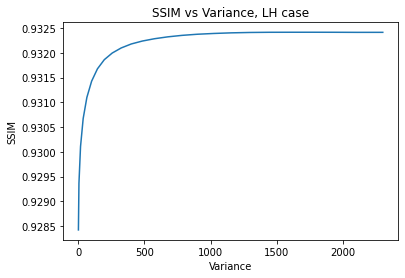

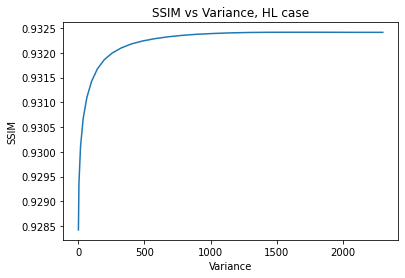

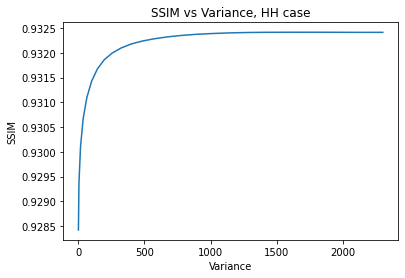

In [14]:
std=0
ssim_valLH=[]
ssim_valHL=[]
ssim_valHH=[]
std_val=[]
while(std<50):
  coeffs2 = pywt.dwt2(imageNoise, 'bior1.3')
  LL, (LH, HL, HH) = coeffs2

  coeff_SoftLH = LL, (softThreshold(LH, threshold(std, 3)), HL, HH)
  img_Soft_LH = pywt.idwt2(coeff_SoftLH, 'haar')
  img_Soft_LH=cv2.resize(img_Soft_LH, (284, 178))
  ssim_valLH.append(SSIM(imgOrig_ques1Gray, img_Soft_LH, 10, 10, 5))

  coeff_SoftHL = LL, (LH, softThreshold(HL, threshold(std, 3)), HH)
  img_Soft_HL = pywt.idwt2(coeff_SoftHL, 'haar')
  img_Soft_HL=cv2.resize(img_Soft_HL, (284, 178))
  ssim_valHL.append(SSIM(imgOrig_ques1Gray, img_Soft_HL, 10, 10, 5))

  coeff_SoftHH = LL, (LH, HL, softThreshold(HH, threshold(std, 3)))
  img_Soft_HH = pywt.idwt2(coeff_SoftHH, 'haar')
  img_Soft_HH=cv2.resize(img_Soft_HH, (284, 178))
  ssim_valHH.append(SSIM(imgOrig_ques1Gray, img_Soft_HH, 10, 10, 5)) 

  std_val.append(std)
  std+=2
  # print(PSNR(imgOrig_ques1Gray, img_NS_LH))

var_arr=np.square(std_val)
plt.plot(var_arr,ssim_valLH)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM vs Variance, LH case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,ssim_valLH)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM vs Variance, HL case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,ssim_valLH)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM vs Variance, HH case')
plt.show()

Hard Thresholding

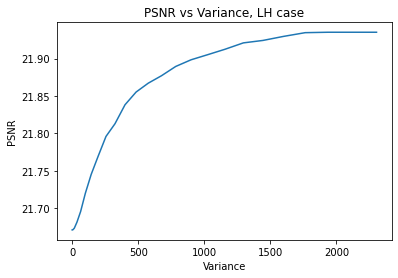

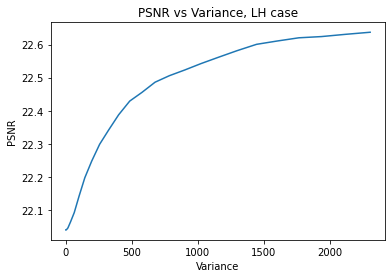

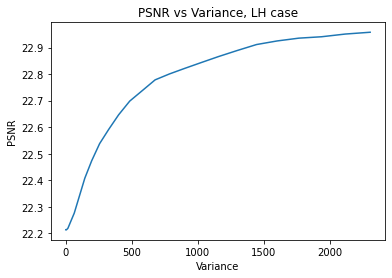

In [11]:
std=0
psnr_valLH=[]
psnr_valHL=[]
psnr_valHH=[]
std_val=[]
while(std < 50):
  coeff = pywt.dwt2(imageNoise, 'bior1.3')
  LL, (LH, HL, HH) = coeff

  coeff_HardLH = LL, (hardThreshold(LH, threshold(std, 3)), HL, HH)
  img_Soft_LH = pywt.idwt2(coeff_HardLH, 'haar')
  img_Soft_LH=cv2.resize(img_Soft_LH, (284, 178))
  psnr_valLH.append(PSNR(imgOrig_ques1Gray, img_Soft_LH))

  coeff_HardHL = LL, (LH, hardThreshold(HL, threshold(std, 3)), HH)
  img_Soft_HL = pywt.idwt2(coeff_HardHL, 'haar')
  img_Soft_HL=cv2.resize(img_Soft_HL, (284, 178))
  psnr_valHL.append(PSNR(imgOrig_ques1Gray, img_Soft_HL))

  coeff_HardHH = LL, (LH, HL, hardThreshold(HH, threshold(std, 3)))
  imgSoft_HH = pywt.idwt2(coeff_HardHH, 'haar')
  imgSoft_HH=cv2.resize(imgSoft_HH, (284, 178))
  psnr_valHH.append(PSNR(imgOrig_ques1Gray, imgSoft_HH))

  std_val.append(std)
  std+=2
  # print(PSNR(imgOrig_ques1Gray, img_NS_LH))

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_valLH)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR vs Variance, LH case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_valHL)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR vs Variance, LH case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,psnr_valHH)
plt.xlabel('Variance')
plt.ylabel('PSNR')
plt.title('PSNR vs Variance, LH case')
plt.show()

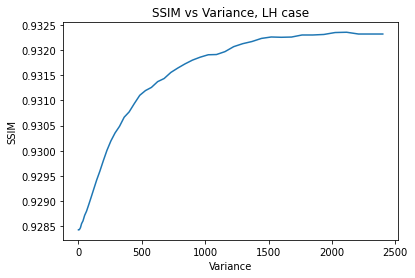

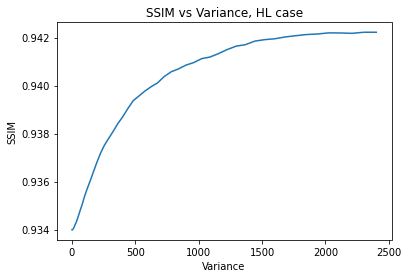

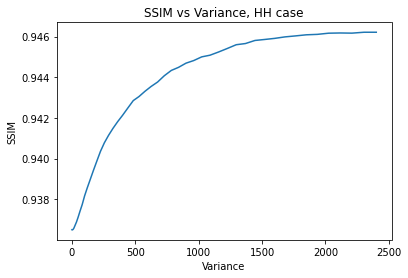

In [15]:
std=0
ssim_valLH=[]
ssim_valHL=[]
ssim_valHH=[]
std_val=[]
while(std<50):
  coeff = pywt.dwt2(imageNoise, 'bior1.3')
  LL, (LH, HL, HH) = coeff

  coeff_HardLH = LL, (hardThreshold(LH, threshold(std, 3)), HL, HH)
  img_Soft_LH = pywt.idwt2(coeff_HardLH, 'haar')
  img_Soft_LH=cv2.resize(img_Soft_LH, (284, 178))
  ssim_valLH.append(SSIM(imgOrig_ques1Gray, img_Soft_LH, 10, 10, 5))

  coeff_HardHL = LL, (LH, hardThreshold(HL, threshold(std, 3)), HH)
  img_Soft_HL = pywt.idwt2(coeff_HardHL, 'haar')
  img_Soft_HL=cv2.resize(img_Soft_HL, (284, 178))
  ssim_valHL.append(SSIM(imgOrig_ques1Gray, img_Soft_HL, 10, 10, 5))

  coeff_HardHH = LL, (LH, HL, hardThreshold(HH, threshold(std, 3)))
  imgSoft_HH = pywt.idwt2(coeff_HardHH, 'haar')
  imgSoft_HH=cv2.resize(imgSoft_HH, (284, 178))
  ssim_valHH.append(SSIM(imgOrig_ques1Gray, imgSoft_HH, 10, 10, 5))

  std_val.append(std)
  std+=1
  # print(PSNR(imgOrig_ques1Gray, img_NS_LH))


var_arr=np.square(std_val)
plt.plot(var_arr,ssim_valLH)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM vs Variance, LH case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,ssim_valHL)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM vs Variance, HL case')
plt.show()

var_arr=np.square(std_val)
plt.plot(var_arr,ssim_valHH)
plt.xlabel('Variance')
plt.ylabel('SSIM')
plt.title('SSIM vs Variance, HH case')
plt.show()